# Analyse non supervisée

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import adjusted_rand_score, silhouette_score
from pathlib import Path
from constants import CANCER, NORMAL, DATA_DIR, PREPARED_DIR, FEATURES_DIR, WITHOUT_LABEL, WITH_LABEL

In [2]:
import mlflow

# On démarre une expérience
mlflow.set_experiment("clustering-kmeans")

RANDOM_STATE = 42
N_COMPONENTS_PCA=30
N_CLUSTERS=2
ALGORITHM="Kmeans"

2026/01/06 08:21:02 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet




Données labellisées: (100, 2048)
Labels: (100,)

Réduction de dimensionnalité avec PCA...
Variance expliquée (50 composantes): 80.10%
Score ARI (données labellisées): 0.669
Répartition clusters unlabeled: [985 421]


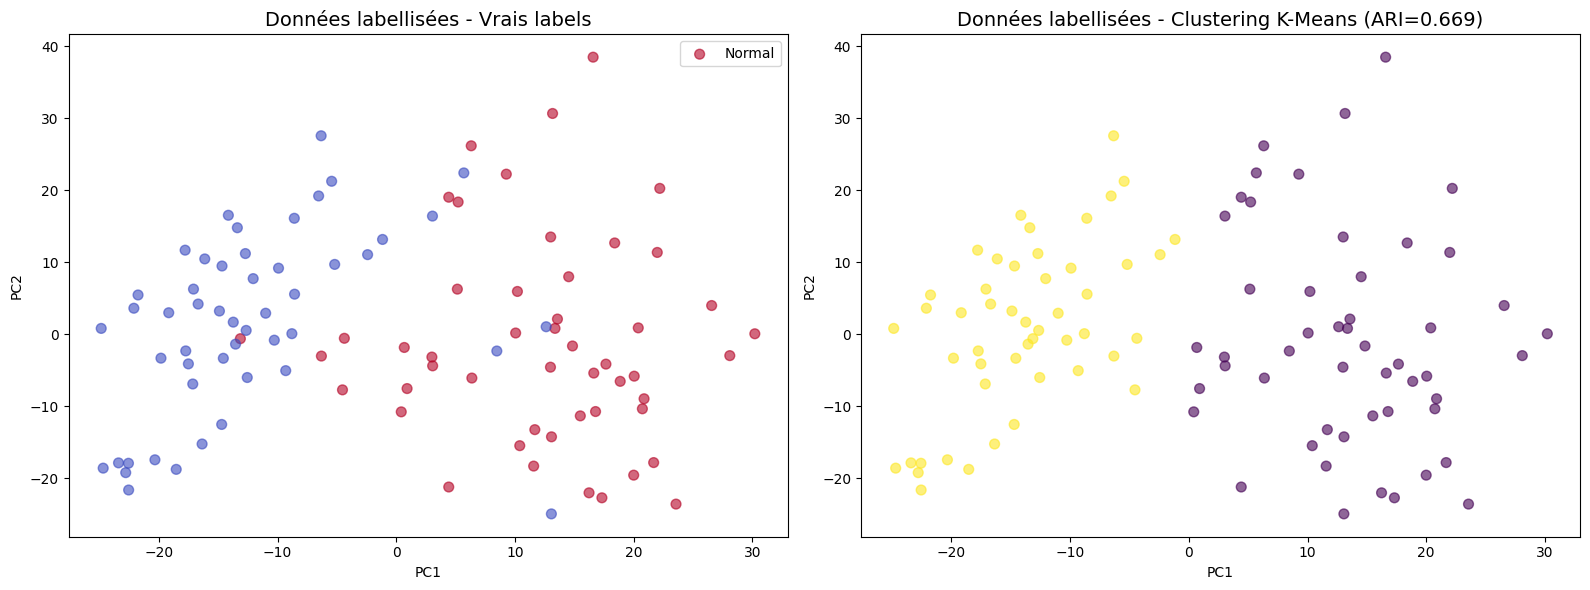

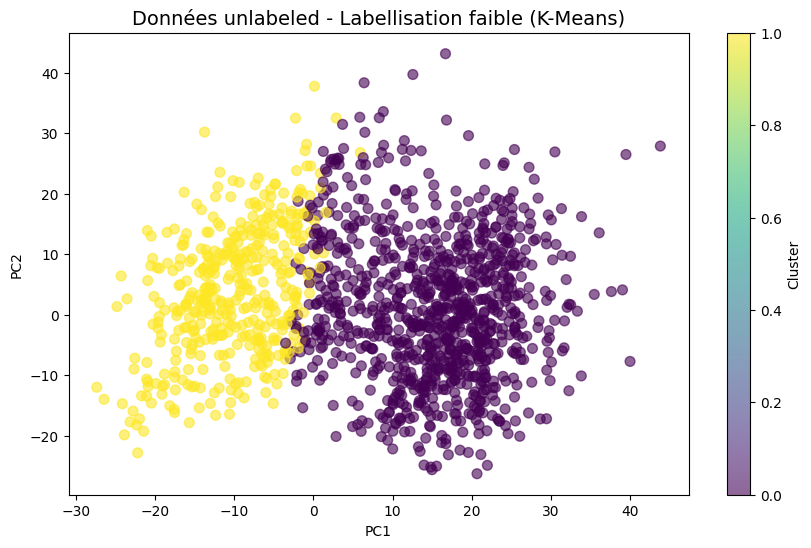

2026/01/06 08:21:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Sauvegarde des labels faibles...
✓ Labels faibles sauvegardés
🏃 View run capricious-shoat-791 at: http://mlflow:5000/#/experiments/458238933919020479/runs/cccc52aa023e498387fac174ef96807f
🧪 View experiment at: http://mlflow:5000/#/experiments/458238933919020479


<Figure size 640x480 with 0 Axes>

In [3]:
# Chargement des features
features_cancer = np.load(FEATURES_DIR / "features_cancer.npy")
features_normal = np.load(FEATURES_DIR / "features_normal.npy")
features_unlabeled = np.load(FEATURES_DIR / "features_unlabeled.npy")

# Préparation des données labelisées (pour évaluation ARI)
X_labeled = np.vstack([features_cancer, features_normal])
y_true = np.array([1]*len(features_cancer) + [0]*len(features_normal))  # 1=cancer, 0=normal

print(f"\nDonnées labellisées: {X_labeled.shape}")
print(f"Labels: {y_true.shape}")

with mlflow.start_run():
    mlflow.log_param("n_components_pca", N_COMPONENTS_PCA)
    mlflow.log_param("cluster_algo", ALGORITHM)
    mlflow.log_param("n_clusters", N_CLUSTERS)

    # Standardisation des features (pixels)
    scaler = StandardScaler()
    X_labeled_scaled = scaler.fit_transform(X_labeled)
    X_unlabeled_scaled = scaler.transform(features_unlabeled)
    
    # Réduction de dimensionnalité avec PCA
    print("\nRéduction de dimensionnalité avec PCA...")
    pca = PCA(n_components=N_COMPONENTS_PCA)
    X_labeled_pca = pca.fit_transform(X_labeled_scaled)
    X_unlabeled_pca = pca.transform(X_unlabeled_scaled)
    
    print(f"Variance expliquée (50 composantes): {pca.explained_variance_ratio_.sum():.2%}")
    
    # PCA 2D pour visualisation
    pca_2d = PCA(n_components=2)
    X_labeled_pca_2d = pca_2d.fit_transform(X_labeled_scaled)
    X_unlabeled_pca_2d = pca_2d.transform(X_unlabeled_scaled)
    
    # CLUSTERING - K-MEANS (k=2)
    kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
    
    # Clustering sur données labellisées (pour évaluation)
    y_pred_labeled = kmeans.fit_predict(X_labeled_pca)
    ari_score = adjusted_rand_score(y_true, y_pred_labeled)
    print(f"Score ARI (données labellisées): {ari_score:.3f}")
    
    # Clustering sur données unlabeled (labellisation faible)
    y_pred_unlabeled = kmeans.predict(X_unlabeled_pca)
    print(f"Répartition clusters unlabeled: {np.bincount(y_pred_unlabeled)}")
    
    # VISUALISATION PCA 2D
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Données labellisées avec vrais labels
    scatter1 = axes[0].scatter(X_labeled_pca_2d[:, 0], X_labeled_pca_2d[:, 1], 
                               c=y_true, cmap='coolwarm', alpha=0.6, s=50)
    axes[0].set_title('Données labellisées - Vrais labels', fontsize=14)
    axes[0].set_xlabel('PC1')
    axes[0].set_ylabel('PC2')
    axes[0].legend(['Normal', 'Cancer'])
    
    # Données labellisées avec prédictions clustering
    scatter2 = axes[1].scatter(X_labeled_pca_2d[:, 0], X_labeled_pca_2d[:, 1], 
                               c=y_pred_labeled, cmap='viridis', alpha=0.6, s=50)
    axes[1].set_title(f'Données labellisées - Clustering K-Means (ARI={ari_score:.3f})', fontsize=14)
    axes[1].set_xlabel('PC1')
    axes[1].set_ylabel('PC2')
    
    plt.tight_layout()
    plt.show()
    
    # VISUALISATION DONNÉES UNLABELED
    plt.figure(figsize=(10, 6))
    plt.scatter(X_unlabeled_pca_2d[:, 0], X_unlabeled_pca_2d[:, 1], 
                c=y_pred_unlabeled, cmap='viridis', alpha=0.6, s=50)
    plt.title('Données unlabeled - Labellisation faible (K-Means)', fontsize=14)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.colorbar(label='Cluster')
    plt.show()
    
    # SAUVEGARDE DES LABELS FAIBLES
    print("\nSauvegarde des labels faibles...")
    np.save(FEATURES_DIR / "weak_labels_unlabeled.npy", y_pred_unlabeled)
    print("✓ Labels faibles sauvegardés")

    # MLFLOW : LOG des métriques
    mlflow.log_metric("ARI", ari_score)
    pca_explained = pca.explained_variance_ratio_.sum()
    mlflow.log_metric("explained_variance", pca_explained)
    
    # Sauvegarde du graphique
    plt.savefig("cluster_plot.png")
    mlflow.log_artifact("cluster_plot.png")
    
    # Sauvegarde du modèle de clustering
    mlflow.sklearn.log_model(kmeans, "model")